# Trajectory classification — Long-GEC-MLP

**Task: trajectory classification.** Visits are flattened into a single
fixed-width feature vector (top-K FDR latent dims × MAX_VISITS + Δt + mask)
and passed to an MLP. No temporal ordering is preserved — this is a
*static* whole-trajectory classifier, NOT early detection.


In [ ]:
# v2 reproducibility seeding — must run before datasets, samplers, or models.
from CLASSIFIER.common.seeding import (
    set_seed, make_rng, make_torch_generator, seed_worker,
)
SEED = 42
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)


# Longitudinal GEC-MLP — Whole-Brain FC Baseline

**Architecture**: Frozen GAAE encoder → top-K FDR latent dimensions per visit → flattened longitudinal vector + time deltas → MLP classifier.

This is the **longitudinal baseline** for comparison against the GELSTM:
instead of processing visits sequentially (LSTM), the MLP receives all visits at once as a fixed-size padded vector `[z_1, z_2, …, z_Nmax, Δt_1, …, Δt_Nmax, mask]`.

**Key design decisions**:
- Top-K FDR dimensions are computed from train+val embeddings (no test leakage)
- Variable-length sequences are handled by zero-padding to `MAX_VISITS` and appending a binary visit-presence mask
- The FDR selection is the same as in `GELSTM_FDR_FILTERED_DELCODE_WHOLE_BRAIN.ipynb` for a fair comparison

In [ ]:
import sys
from pathlib import Path
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(model_root))

In [7]:
import json, os, copy, warnings, glob as _glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report
)
from torch_geometric.utils import unbatch
from torch_geometric.loader import DataLoader as PyGLoader
from model.GAAE.models   import GraphAttentionAutoencoderConditioned
from model.GAAE.dataset  import GraphDatasetInMemoryFiltered
from model.GAAE.utils    import knn_binary_adjacency_matrix_no_diag
from model.GELSTM.dataset import LongitudinalSubjectDataset
warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## Configuration

In [9]:
RANDOM_STATE = 42
set_seed(RANDOM_STATE)

# ── Paths ────────────────────────────────────────────────────────────────
WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohorts.csv')
SPLITS_DIR   = os.path.join(METADATA_DIR, 'splits_gaae')
TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints_gaae_whole_brain'),
]
OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints_longitudinal_gec_mlp')
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIG_PATH = model_root / 'configs' / 'gaae_delcode_whole_brain.json'

# ── FDR selection ─────────────────────────────────────────────────────────
TOP_K = 15   # same as GELSTM_FDR_FILTERED for fair comparison

# ── Longitudinal padding ──────────────────────────────────────────────────
# Patients are padded to MAX_VISITS visits.  Set to None to auto-detect from data.
MAX_VISITS = None   # will be set after dataset discovery

# ── MLP hyper-params ──────────────────────────────────────────────────────
MLP_HIDDEN_LAYERS = [256, 128, 64]   # hidden layer widths
MLP_DROPOUT       = 0.4
USE_TIME_DELTA    = True
APPEND_VISIT_MASK = True   # binary mask appended to flag padded positions

# ── Training ──────────────────────────────────────────────────────────────
LEARNING_RATE           = 1e-3
EPOCHS                  = 80
EARLY_STOPPING_PATIENCE = 20
BATCH_SIZE              = 32
GRAD_CLIP               = 1.0

# ── CV ────────────────────────────────────────────────────────────────────
N_FOLDS = 5

# GAAE graph construction
ADJ_K        = 8
FILE_VARIANT = 'z_transformed'

print('Config set.')


Config set.


In [ ]:
# v2 split-hygiene audit — hard-fails if any subject crosses splits.
import sys
from pathlib import Path
_V2_ROOT = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(_V2_ROOT) not in sys.path:
    sys.path.insert(0, str(_V2_ROOT))
from common.sanity import run_full_audit
if 'METADATA_DIR' in globals():
    _splits_dir = Path(METADATA_DIR) / 'splits_gaae'
    _ = run_full_audit({
        'train': str(_splits_dir / 'train.csv'),
        'val':   str(_splits_dir / 'val.csv'),
        'test':  str(_splits_dir / 'test.csv'),
    })
else:
    print('[SANITY] METADATA_DIR not defined in this notebook — skipping split audit')


## Select GAAE Checkpoint

In [10]:
checkpoint_candidates = sorted(
    [(run_dir.name, str(run_dir / f'model_{run_dir.name}.pth'), str(run_dir))
     for ckpt_dir in CHECKPOINT_SEARCH_DIRS
     for base_path in [Path(ckpt_dir)] if base_path.is_dir()
     for run_dir in sorted(base_path.iterdir()) if run_dir.is_dir()
     if (run_dir / f'model_{run_dir.name}.pth').exists()],
    key=lambda x: x[0],
)
if not checkpoint_candidates:
    raise FileNotFoundError('No GAAE checkpoints found in CHECKPOINT_SEARCH_DIRS.')
print('Available GAAE checkpoints:')
for i, (name, _, _) in enumerate(checkpoint_candidates): print(f'  {i}: {name}')
selected_idx = int(input('Select checkpoint index: '))
GAAE_RUN_NAME, GAAE_CKPT_PATH, GAAE_RUN_DIR = checkpoint_candidates[selected_idx]
print(f'Selected: {GAAE_RUN_NAME}')


Available GAAE checkpoints:
  0: bright-disco-4_2026-05-07_20-17-11
  1: worldly-plasma-2_2026-03-24_01-00-18
Selected: bright-disco-4_2026-05-07_20-17-11


## Load GAAE Config

In [11]:
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f: hp = json.load(f)
    print('Config:', hp)
else:
    hp = dict(latent_dim=64, num_heads=2, cond_dim=2, dropout=0.3,
              adjacency_k=8, file_variant='z_transformed')
    print('Using defaults.')

IN_FEATURES   = 200
GAAE_HIDDEN   = IN_FEATURES
GAAE_LATENT   = hp.get('latent_dim', 64)
GAAE_HEADS    = hp.get('num_heads', 2)
GAAE_COND_DIM = hp.get('cond_dim', 2)
GAAE_DROPOUT  = hp.get('dropout', 0.3)
ADJ_K         = hp.get('adjacency_k', ADJ_K)
FILE_VARIANT  = hp.get('file_variant', FILE_VARIANT)
print(f'GAAE latent dim: {GAAE_LATENT}  →  using top-{TOP_K} FDR dims')


Config: {'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'adj_loss_weight': 0.1, 'epochs': 1000, 'early_stopping_patience': 100, 'latent_dim': 64, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 8, 'num_workers': 8, 'file_variant': 'z_transformed', 'dense_use_abs': False, 'model_save_path': None}
GAAE latent dim: 64  →  using top-15 FDR dims


## FDR Dimension Selection (train+val only)

Identical to `GELSTM_FDR_FILTERED_DELCODE_WHOLE_BRAIN.ipynb` — computes Fisher's Discriminant Ratio per latent dimension on train+val MCI embeddings to select the `TOP_K` most discriminative dimensions. No test data used.

In [12]:
import tempfile

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
mci_pool   = cv_pool_df[cv_pool_df['diagnosis'].isin(['mci','converter'])].copy()
test_mci   = test_df[test_df['diagnosis'].isin(['mci','converter'])].copy()

ALL_INFO_CSV = os.path.join(SPLITS_DIR, '_all_splits_patient_info.csv')
if not os.path.exists(ALL_INFO_CSV):
    _info = pd.concat(
        [df[['Repseudonym','sex','age']] for df in [train_df, val_df, test_df]],
        ignore_index=True,
    ).drop_duplicates('Repseudonym').reset_index(drop=True)
    _info.to_csv(ALL_INFO_CSV, index=False)

# Build scan-level dataset for FDR (train+val MCI only)
_tmp = tempfile.NamedTemporaryFile(suffix='.csv', delete=False, mode='w')
mci_pool.to_csv(_tmp.name, index=False); _tmp.close()

fdr_dataset = GraphDatasetInMemoryFiltered(
    root=WB_DATA_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args={'k': ADJ_K},
    filter_csv_path=_tmp.name,
    patient_info_path=ALL_INFO_CSV,
    separator=',',
    file_variant=FILE_VARIANT,
)
print(f'FDR dataset: {len(fdr_dataset)} scans')


Processing...
Done!


FDR dataset: 422 scans


In [13]:
# Load GAAE encoder
gaae_enc = GraphAttentionAutoencoderConditioned(
    in_features=IN_FEATURES, hidden_dim=GAAE_HIDDEN,
    out_features=GAAE_LATENT, cond_dim=GAAE_COND_DIM,
    num_heads=GAAE_HEADS, dropout=GAAE_DROPOUT,
).to(device)
ckpt_obj = torch.load(GAAE_CKPT_PATH, map_location=device, weights_only=False)
gaae_enc.load_state_dict(ckpt_obj if isinstance(ckpt_obj, dict) else ckpt_obj.state_dict())
gaae_enc.eval()
for p in gaae_enc.parameters(): p.requires_grad_(False)
print('GAAE encoder loaded and frozen.')

# Encode all train+val MCI scans
fdr_loader = PyGLoader(fdr_dataset, batch_size=32, shuffle=False)
fdr_embs, fdr_labels = [], []
id2diag_cv = dict(zip(mci_pool['Repseudonym'].astype(str), mci_pool['diagnosis']))

gaae_enc.eval()
with torch.no_grad():
    for batch in fdr_loader:
        batch = batch.to(device)
        z = gaae_enc.encode(batch.x, batch.edge_index, batch.edge_attr)
        z_list = unbatch(z, batch.batch)
        pids = batch.patient_id if isinstance(batch.patient_id, list) else [batch.patient_id]
        for z_g, pid in zip(z_list, pids):
            emb = z_g.mean(0).cpu().numpy()
            pid_str = str(pid).split('_')[0] if '_' in str(pid) else str(pid)
            diag = id2diag_cv.get(pid_str, 'mci')
            fdr_embs.append(emb)
            fdr_labels.append(1 if diag == 'converter' else 0)

fdr_embs   = np.stack(fdr_embs)
fdr_labels = np.array(fdr_labels)
print(f'Encoded {fdr_embs.shape[0]} scans  conv={fdr_labels.sum()}  mci={(1-fdr_labels).sum()}')


GAAE encoder loaded and frozen.
Encoded 422 scans  conv=177  mci=245


Top-15 dimensions (FDR):
  # 1  dim_ 59  FDR=0.5776
  # 2  dim_ 24  FDR=0.4558
  # 3  dim_ 18  FDR=0.4025
  # 4  dim_ 30  FDR=0.3820
  # 5  dim_ 16  FDR=0.3474
  # 6  dim_ 56  FDR=0.3022
  # 7  dim_ 45  FDR=0.2899
  # 8  dim_ 63  FDR=0.2855
  # 9  dim_ 46  FDR=0.2815
  #10  dim_ 31  FDR=0.2752
  #11  dim_ 51  FDR=0.2464
  #12  dim_ 47  FDR=0.2315
  #13  dim_ 32  FDR=0.2217
  #14  dim_ 19  FDR=0.2063
  #15  dim_ 38  FDR=0.2025


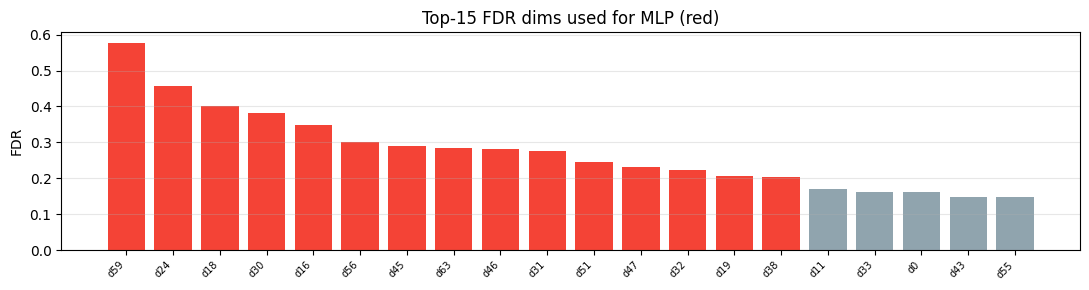

In [14]:
# Compute FDR scores and select top-K dims
conv_e = fdr_embs[fdr_labels == 1]
mci_e  = fdr_embs[fdr_labels == 0]
mu_c, mu_m = conv_e.mean(0), mci_e.mean(0)
vc, vm     = conv_e.var(0) + 1e-8, mci_e.var(0) + 1e-8
fdr_scores = (mu_c - mu_m) ** 2 / (vc + vm)
top_dims   = np.argsort(fdr_scores)[::-1]
DIM_FILTER = top_dims[:TOP_K].copy()

print(f'Top-{TOP_K} dimensions (FDR):')
for rank, d in enumerate(DIM_FILTER):
    print(f'  #{rank+1:2d}  dim_{d:3d}  FDR={fdr_scores[d]:.4f}')

# Quick bar chart
fig, ax = plt.subplots(figsize=(11, 3))
n_show = min(20, GAAE_LATENT)
colors = ['#F44336' if d in set(DIM_FILTER) else '#90A4AE' for d in top_dims[:n_show]]
ax.bar(range(n_show), fdr_scores[top_dims[:n_show]], color=colors)
ax.set_xticks(range(n_show))
ax.set_xticklabels([f'd{d}' for d in top_dims[:n_show]], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('FDR'); ax.set_title(f'Top-{TOP_K} FDR dims used for MLP (red)')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


## Build Longitudinal Flat-Vector Dataset

For each subject, collect all scans in visit order:
1. Encode each scan through the frozen GAAE → `z_t[DIM_FILTER] ∈ R^TOP_K`
2. Compute inter-visit time deltas `Δt_t` (normalised)
3. Pad to `MAX_VISITS`: `[z_1, …, z_N, 0, …, 0]` + `[mask_1, …, mask_N, 0, …, 0]`
4. Final per-subject feature vector: `TOP_K × MAX_VISITS + MAX_VISITS (Δt) + MAX_VISITS (mask)`

In [15]:
def encode_graph_to_z(data):
    """Encode a PyG Data graph to a per-graph embedding using the frozen GAAE."""
    x  = data.x.to(device)
    ei = data.edge_index.to(device)
    ea = data.edge_attr.to(device) if data.edge_attr is not None else None
    z_nodes = gaae_enc.encode(x, ei, ea)       # (N_nodes, GAAE_LATENT)
    z_graph = z_nodes.mean(0).cpu().numpy()    # (GAAE_LATENT,)
    return z_graph[DIM_FILTER]                 # (TOP_K,)


def build_longitudinal_dataset(subject_dataset: LongitudinalSubjectDataset):
    """
    Returns (X, y, groups) where:
      X      : (N_subjects, feature_dim)  padded flat longitudinal vector
      y      : (N_subjects,)              labels {0,1}
      groups : list of subject IDs for StratifiedGroupKFold
    """
    records = []
    gaae_enc.eval()
    with torch.no_grad():
        for i in range(len(subject_dataset)):
            item = subject_dataset[i]
            graphs = item['graphs']     # list of PyG Data, chronological order
            deltas = item['delta_t']    # list of normalised Δt values
            label  = item['label']      # 0=MCI, 1=converter
            pid    = item['subject_id']
            T      = len(graphs)
            zs  = [encode_graph_to_z(g) for g in graphs]  # list of (TOP_K,)
            dts = list(deltas)
            records.append({'pid': pid, 'label': label, 'T': T, 'zs': zs, 'dts': dts})
    return records


def records_to_arrays(records, max_visits):
    """Convert records to padded numpy arrays."""
    n    = len(records)
    k    = TOP_K
    X_z  = np.zeros((n, max_visits * k),   dtype=np.float32)  # latent features
    X_dt = np.zeros((n, max_visits),        dtype=np.float32)  # time deltas
    X_m  = np.zeros((n, max_visits),        dtype=np.float32)  # visit mask
    y    = np.zeros(n,                      dtype=np.float32)
    groups = []

    for i, rec in enumerate(records):
        T = min(rec['T'], max_visits)
        for t in range(T):
            X_z[i, t*k:(t+1)*k] = rec['zs'][t]
            X_dt[i, t]          = rec['dts'][t]
            X_m[i, t]           = 1.0
        y[i] = float(rec['label'])
        groups.append(rec['pid'])

    parts = [X_z]
    if USE_TIME_DELTA:    parts.append(X_dt)
    if APPEND_VISIT_MASK: parts.append(X_m)
    X = np.concatenate(parts, axis=1)
    return X.astype(np.float32), y.astype(np.float32), groups


In [16]:
# Build longitudinal datasets
cv_long_ds = LongitudinalSubjectDataset(
    WB_DATA_ROOT, mci_pool, COHORTS_CSV, adjacency_k=ADJ_K, file_variant=FILE_VARIANT
)
te_long_ds = LongitudinalSubjectDataset(
    WB_DATA_ROOT, test_mci, COHORTS_CSV, adjacency_k=ADJ_K, file_variant=FILE_VARIANT
)
print(f'CV subjects: {len(cv_long_ds)}  Test subjects: {len(te_long_ds)}')

# Auto-detect MAX_VISITS from CV pool
print('Discovering visit counts...')
visit_counts = [len(cv_long_ds[i]['graphs']) for i in range(len(cv_long_ds))]
if MAX_VISITS is None:
    MAX_VISITS = int(max(visit_counts))
print(f'MAX_VISITS = {MAX_VISITS}  (distribution: {pd.Series(visit_counts).value_counts().sort_index().to_dict()})')

# Encode all subjects into longitudinal flat vectors
print('Encoding CV pool...')
cv_records = build_longitudinal_dataset(cv_long_ds)
X_cv, y_cv, groups_cv = records_to_arrays(cv_records, MAX_VISITS)

print('Encoding test set...')
te_records = build_longitudinal_dataset(te_long_ds)
X_te, y_te, groups_te = records_to_arrays(te_records, MAX_VISITS)

feat_dim = X_cv.shape[1]
print(f'CV array: {X_cv.shape}  Test array: {X_te.shape}')
print(f'Feature dim breakdown: {TOP_K}×{MAX_VISITS}={TOP_K*MAX_VISITS} (z) + '
      f'{MAX_VISITS} (Δt) + {MAX_VISITS} (mask) = {feat_dim}')


LongitudinalSubjectDataset: 141 subjects (52 converter, 89 stable MCI)
  Scans per subject: min=1  max=6  mean=3.0
LongitudinalSubjectDataset: 16 subjects (6 converter, 10 stable MCI)
  Scans per subject: min=1  max=5  mean=3.0
CV subjects: 141  Test subjects: 16
Discovering visit counts...
MAX_VISITS = 6  (distribution: {1: 30, 2: 38, 3: 22, 4: 22, 5: 15, 6: 14})
Encoding CV pool...
Encoding test set...
CV array: (141, 102)  Test array: (16, 102)
Feature dim breakdown: 15×6=90 (z) + 6 (Δt) + 6 (mask) = 102


## MLP Model Architecture

Input: `TOP_K × MAX_VISITS + MAX_VISITS (Δt) + MAX_VISITS (mask)` flat vector

The MLP sees the entire visit history simultaneously — no temporal order is assumed. This is the key difference vs. the LSTM, which processes visits sequentially and is sensitive to temporal ordering. The MLP comparison tells us whether temporal ordering/recurrence actually helps beyond having all the data in one vector.

In [17]:
class LongitudinalMLP(nn.Module):
    """
    MLP classifier for longitudinal data.
    Input: padded flat vector [z_1,...,z_Nmax, Δt_1,..., Δt_Nmax, mask_1,...,mask_Nmax]
    """
    def __init__(self, input_dim: int, hidden_layers: list[int], dropout: float = 0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, input_dim) → (B,) logits."""
        return self.net(x).squeeze(-1)


def build_mlp():
    m = LongitudinalMLP(
        input_dim=feat_dim,
        hidden_layers=MLP_HIDDEN_LAYERS,
        dropout=MLP_DROPOUT,
    ).to(device)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'LongitudinalMLP: input={feat_dim}  params={n_params:,}')
    return m

_ = build_mlp()


LongitudinalMLP: input=102  params=68,481


## 5-Fold Stratified Subject-Level Cross-Validation

In [18]:
# Standardise features on train split only (fit per fold)
cv_results = {'fold':[],'val_auc':[],'val_sensitivity':[],'val_specificity':[],'val_f1':[],'best_threshold':[]}
cv_histories = {'train_loss':[],'val_loss':[]}
oof_probs, oof_tgts, oof_sids = [], [], []

best_val_auc, best_fold, best_model_state = 0.0, -1, None
best_threshold_overall = 0.5

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS)

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X_cv, y_cv, groups=groups_cv)):
    print(f'\n{"="*55}')
    print(f'Fold {fold+1}/{N_FOLDS}  train={len(tr_idx)}  val={len(va_idx)}')

    X_tr_raw, y_tr = X_cv[tr_idx], y_cv[tr_idx]
    X_va_raw, y_va = X_cv[va_idx], y_cv[va_idx]

    # Standardise on train fold only
    scaler = StandardScaler().fit(X_tr_raw)
    X_tr   = torch.tensor(scaler.transform(X_tr_raw), dtype=torch.float32)
    X_va   = torch.tensor(scaler.transform(X_va_raw), dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.float32)

    # Class-weighted loss
    n_pos = int(y_tr.sum()); n_neg = len(y_tr) - n_pos
    pos_w = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    model = build_mlp()
    opt   = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=7)

    tr_ds = torch.utils.data.TensorDataset(X_tr, y_tr_t)
    tr_dl = torch.utils.data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_fold_auc, no_improve = 0.0, 0
    best_fold_state = None
    fold_tr_losses, fold_va_aucs = [], []

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)
            opt.zero_grad(); loss.backward()
            if GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            total_loss += loss.item()
        tr_loss = total_loss / max(len(tr_dl), 1)

        model.eval()
        with torch.no_grad():
            logits_va = model(X_va.to(device))
            probs_va  = torch.sigmoid(logits_va).cpu().numpy()
        va_auc = roc_auc_score(y_va, probs_va) if len(np.unique(y_va)) > 1 else 0.0
        sched.step(va_auc)

        fold_tr_losses.append(tr_loss)
        fold_va_aucs.append(va_auc)

        if (epoch + 1) % 10 == 0:
            print(f'  Ep {epoch+1:3d}/{EPOCHS}  loss={tr_loss:.4f}  val_auc={va_auc:.4f}')

        if va_auc > best_fold_auc:
            best_fold_auc = va_auc
            best_fold_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= EARLY_STOPPING_PATIENCE:
                print(f'  Early stop at epoch {epoch+1}')
                break

    # Reload best and evaluate
    model.load_state_dict(best_fold_state)
    model.eval()
    with torch.no_grad():
        probs_va2 = torch.sigmoid(model(X_va.to(device))).cpu().numpy()
    auc_fold = roc_auc_score(y_va, probs_va2) if len(np.unique(y_va)) > 1 else 0.0
    fpr_,tpr_,thr_ = roc_curve(y_va, probs_va2) if len(np.unique(y_va)) > 1 else ([0],[1],[0.5])
    best_thr = float(thr_[np.argmax(np.array(tpr_)-np.array(fpr_))])
    pred_va  = (probs_va2 >= best_thr).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_va.astype(int), pred_va).ravel() if len(np.unique(y_va)) > 1 else (0,0,0,0)
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
    f1   = f1_score(y_va.astype(int), pred_va, zero_division=0)

    oof_probs.extend(probs_va2.tolist())
    oof_tgts.extend(y_va.astype(int).tolist())
    oof_sids.extend([groups_cv[i] for i in va_idx])

    cv_results['fold'].append(fold+1)
    cv_results['val_auc'].append(auc_fold)
    cv_results['val_sensitivity'].append(sens)
    cv_results['val_specificity'].append(spec)
    cv_results['val_f1'].append(f1)
    cv_results['best_threshold'].append(best_thr)
    cv_histories['train_loss'].append(fold_tr_losses)
    cv_histories['val_loss'].append(fold_va_aucs)

    print(f'  Best AUC={auc_fold:.4f}  sens={sens:.3f}  spec={spec:.3f}  F1={f1:.3f}')
    if auc_fold > best_val_auc:
        best_val_auc, best_fold = auc_fold, fold+1
        best_model_state = best_fold_state
        best_threshold_overall = best_thr
        best_scaler = scaler

oof_arr = np.array(oof_probs); oof_tgt = np.array(oof_tgts)
_, _, thrs = roc_curve(oof_tgt, oof_arr)
best_f1_thr = float(thrs[np.argmax([f1_score(oof_tgt,(oof_arr>=t).astype(int),zero_division=0) for t in thrs])])
print(f'\nBest fold: {best_fold}  CV AUC={best_val_auc:.4f}')
print(f'Youden thr={best_threshold_overall:.4f}  OOF-F1 thr={best_f1_thr:.4f}')



Fold 1/5  train=112  val=29
LongitudinalMLP: input=102  params=68,481
  Ep  10/80  loss=0.4646  val_auc=0.8939
  Ep  20/80  loss=0.2634  val_auc=0.8889
  Early stop at epoch 29
  Best AUC=0.9040  sens=0.818  spec=0.889  F1=0.818

Fold 2/5  train=113  val=28
LongitudinalMLP: input=102  params=68,481
  Ep  10/80  loss=0.4477  val_auc=0.8500
  Ep  20/80  loss=0.2863  val_auc=0.8611
  Ep  30/80  loss=0.3166  val_auc=0.8444
  Ep  40/80  loss=0.2192  val_auc=0.8444
  Early stop at epoch 41
  Best AUC=0.8722  sens=0.700  spec=0.944  F1=0.778

Fold 3/5  train=113  val=28
LongitudinalMLP: input=102  params=68,481
  Ep  10/80  loss=0.5193  val_auc=0.9444
  Ep  20/80  loss=0.3773  val_auc=0.9389
  Ep  30/80  loss=0.3101  val_auc=0.9333
  Early stop at epoch 34
  Best AUC=0.9556  sens=0.900  spec=1.000  F1=0.947

Fold 4/5  train=113  val=28
LongitudinalMLP: input=102  params=68,481
  Ep  10/80  loss=0.5317  val_auc=0.8333
  Ep  20/80  loss=0.3142  val_auc=0.7778
  Early stop at epoch 27
  Best AU

## Cross-Validation Summary

In [19]:
print('Cross-Validation Summary (Longitudinal GEC-MLP):')
print('=' * 60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print('-' * 60)
for m in ['val_auc','val_sensitivity','val_specificity','val_f1']:
    v = cv_results[m]
    print(f'{m:<20} {np.mean(v):>10.4f} {np.std(v):>10.4f} {np.min(v):>10.4f} {np.max(v):>10.4f}')


Cross-Validation Summary (Longitudinal GEC-MLP):
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.9143     0.0487     0.8556     0.9840
val_sensitivity          0.8436     0.1008     0.7000     1.0000
val_specificity          0.9098     0.0572     0.8333     1.0000
val_f1                   0.8444     0.0745     0.7619     0.9474


In [20]:
def _oof_m(thr):
    p = (oof_arr >= thr).astype(int)
    if len(np.unique(oof_tgt)) > 1:
        tn,fp,fn,tp = confusion_matrix(oof_tgt,p).ravel()
    else: tn=fp=fn=tp=0
    return tp/(tp+fn+1e-9), tn/(tn+fp+1e-9), f1_score(oof_tgt,p,zero_division=0)
y_s,y_sp,y_f1 = _oof_m(best_threshold_overall)
f_s,f_sp,f_f1 = _oof_m(best_f1_thr)
print(f'[1] Youden  thr={best_threshold_overall:.4f}  sens={y_s:.3f}  spec={y_sp:.3f}  F1={y_f1:.3f}')
print(f'[2] Best-F1 thr={best_f1_thr:.4f}  sens={f_s:.3f}  spec={f_sp:.3f}  F1={f_f1:.3f}')
choice = input('Select [1=Youden, 2=Best-F1]: ').strip()
ACTIVE_THRESHOLD = best_f1_thr if choice == '2' else best_threshold_overall
THRESHOLD_METHOD = 'oof_f1' if choice == '2' else 'oof_youden'
print(f'Using {THRESHOLD_METHOD}: {ACTIVE_THRESHOLD:.4f}')


[1] Youden  thr=0.3777  sens=0.904  spec=0.573  F1=0.686
[2] Best-F1 thr=0.5176  sens=0.827  spec=0.831  F1=0.782
Using oof_f1: 0.5176


## Save Best Model

In [21]:
run_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
run_name      = f'long_gec_mlp_{TOP_K}dims_{run_timestamp}'
run_dir       = Path(OUTPUT_DIR) / run_name
run_dir.mkdir(parents=True, exist_ok=True)

torch.save(best_model_state, run_dir / f'model_{run_name}.pth')
np.save(run_dir / 'dim_filter.npy', DIM_FILTER)
import pickle
with open(run_dir / 'scaler.pkl', 'wb') as _f: pickle.dump(best_scaler, _f)

run_summary = {
    'run_name': run_name, 'gaae_checkpoint': GAAE_RUN_NAME,
    'top_k': TOP_K, 'dim_filter': DIM_FILTER.tolist(),
    'max_visits': MAX_VISITS, 'feat_dim': feat_dim,
    'n_folds': N_FOLDS, 'best_fold': int(best_fold),
    'best_val_auc': float(best_val_auc),
    'active_threshold': float(ACTIVE_THRESHOLD),
    'threshold_method': THRESHOLD_METHOD,
    'mlp_hidden_layers': MLP_HIDDEN_LAYERS,
    'cv_results': cv_results,
}
with open(run_dir / 'run_summary.json', 'w') as _f:
    json.dump(run_summary, _f, indent=2)
print(f'Saved to {run_dir}')


Saved to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_longitudinal_gec_mlp/long_gec_mlp_15dims_2026-05-08_10-28-54


## Test-Set Evaluation

In [22]:
eval_mlp = build_mlp()
eval_mlp.load_state_dict(best_model_state)
eval_mlp.eval()

X_te_scaled = torch.tensor(best_scaler.transform(X_te), dtype=torch.float32)
with torch.no_grad():
    te_logits = eval_mlp(X_te_scaled.to(device))
    te_probs  = torch.sigmoid(te_logits).cpu().numpy()

te_preds = (te_probs >= ACTIVE_THRESHOLD).astype(int)
te_auc   = roc_auc_score(y_te, te_probs) if len(np.unique(y_te)) > 1 else 0.0
tn,fp,fn,tp = confusion_matrix(y_te.astype(int), te_preds).ravel() if len(np.unique(y_te)) > 1 else (0,0,0,0)
te_sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
te_spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
te_f1   = f1_score(y_te.astype(int), te_preds, zero_division=0)
print(f'Test AUC={te_auc:.4f}  Sens={te_sens:.4f}  Spec={te_spec:.4f}  F1={te_f1:.4f}')
print()
print(classification_report(y_te.astype(int), te_preds, target_names=['stable_mci','converter']))


# ── Back-patch run_summary.json with test metrics ────────────
with open(run_dir / 'run_summary.json') as _f:
    _s = json.load(_f)
_s.update({
    'test_auc':          float(te_auc),
    'test_sensitivity':  float(te_sens),
    'test_specificity':  float(te_spec),
    'test_f1':           float(te_f1),
    'test_probabilities': te_probs.tolist() if hasattr(te_probs,'tolist') else list(te_probs),
    'test_labels':        y_te.tolist() if hasattr(y_te,'tolist') else list(y_te),
})
with open(run_dir / 'run_summary.json', 'w') as _f:
    json.dump(_s, _f, indent=2)
print(f'Test metrics saved to {run_dir / "run_summary.json"}')


LongitudinalMLP: input=102  params=68,481
Test AUC=1.0000  Sens=1.0000  Spec=1.0000  F1=1.0000

              precision    recall  f1-score   support

  stable_mci       1.00      1.00      1.00        10
   converter       1.00      1.00      1.00         6

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16

Test metrics saved to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_longitudinal_gec_mlp/long_gec_mlp_15dims_2026-05-08_10-28-54/run_summary.json


## ROC Curves

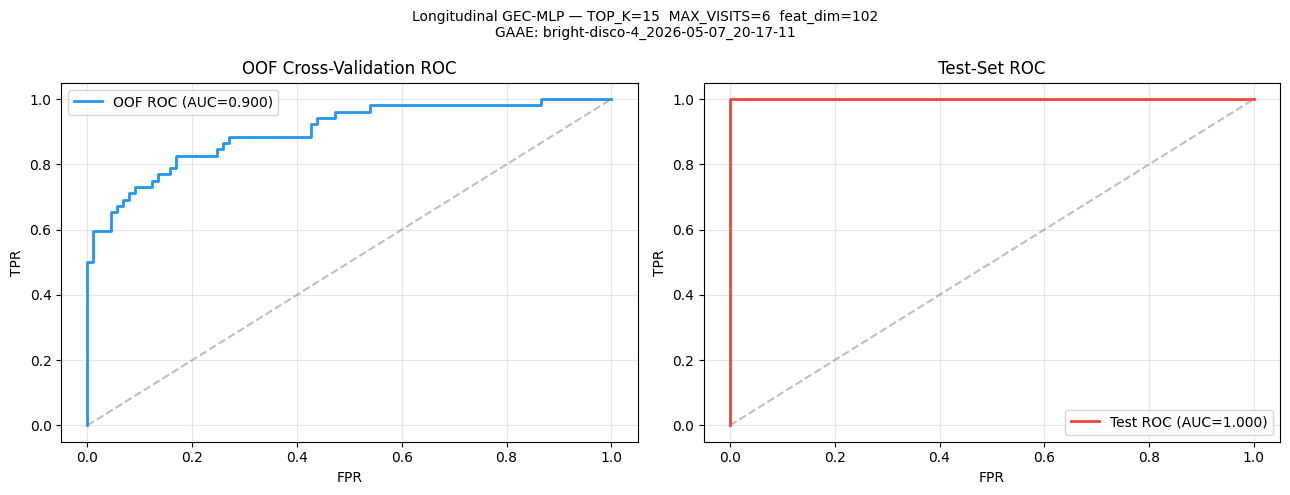

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: OOF ROC
ax = axes[0]
fpr_oof, tpr_oof, _ = roc_curve(oof_tgt, oof_arr)
auc_oof = roc_auc_score(oof_tgt, oof_arr)
ax.plot(fpr_oof, tpr_oof, lw=2, color='#2196F3',
        label=f'OOF ROC (AUC={auc_oof:.3f})')
ax.plot([0,1],[0,1],'--',color='grey',alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('OOF Cross-Validation ROC')
ax.legend(); ax.grid(alpha=0.3)

# Right: test ROC
ax = axes[1]
fpr_te, tpr_te, _ = roc_curve(y_te.astype(int), te_probs)
ax.plot(fpr_te, tpr_te, lw=2, color='#F44336',
        label=f'Test ROC (AUC={te_auc:.3f})')
ax.plot([0,1],[0,1],'--',color='grey',alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Test-Set ROC')
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle(
    f'Longitudinal GEC-MLP — TOP_K={TOP_K}  MAX_VISITS={MAX_VISITS}  '
    f'feat_dim={feat_dim}\n'
    f'GAAE: {GAAE_RUN_NAME}',
    fontsize=10,
)
plt.tight_layout(); plt.show()


## Stratified Evaluation by Number of Scans

In [24]:
strat_records = []
for i, rec in enumerate(te_records):
    strat_records.append({'n_scans': rec['T'], 'prob': te_probs[i], 'true': int(y_te[i])})
strat_df = pd.DataFrame(strat_records)

print(f'\n{"Scans":>6} {"N":>4} {"AUC":>8} {"Sens":>8} {"Spec":>8}')
print('-' * 40)
for n_sc, grp in sorted(strat_df.groupby('n_scans')):
    if grp['true'].nunique() < 2 or len(grp) < 4:
        continue
    sc_auc = roc_auc_score(grp['true'], grp['prob'])
    sc_pred = (grp['prob'] >= ACTIVE_THRESHOLD).astype(int)
    cm_sc = confusion_matrix(grp['true'], sc_pred)
    tn_,fp_,fn_,tp_ = cm_sc.ravel() if cm_sc.size == 4 else (0,0,0,0)
    sc_sens = tp_/(tp_+fn_+1e-9)
    sc_spec = tn_/(tn_+fp_+1e-9)
    print(f'{n_sc:>6} {len(grp):>4} {sc_auc:>8.4f} {sc_sens:>8.3f} {sc_spec:>8.3f}')



 Scans    N      AUC     Sens     Spec
----------------------------------------
     2    6   1.0000    1.000    1.000
     5    4   1.0000    1.000    1.000


## Comparison vs GELSTM FDR-Filtered

Loads the most recent `GELSTM_FDR_FILTERED` run summary (if available) and prints a side-by-side AUC comparison.

> **Interpretation**: If LSTM AUC > MLP AUC, the temporal ordering of visits adds predictive information beyond having all the data in a flat vector. If MLP ≈ LSTM, the visits are nearly exchangeable and simple concatenation suffices.

In [25]:
print('Longitudinal GEC-MLP (this run):')
print(f'  CV  AUC: {np.mean(cv_results["val_auc"]):.4f} ± {np.std(cv_results["val_auc"]):.4f}')
print(f'  Test AUC: {te_auc:.4f}')
print(f'  Input: TOP_K={TOP_K} dims × MAX_VISITS={MAX_VISITS} visits = {feat_dim} features')

# Load GELSTM FDR runs
gelstm_dir = str(model_root / 'notebooks' / 'checkpoints_gelstm_fdr_filtered')
gelstm_summaries = sorted(_glob.glob(f'{gelstm_dir}/**/run_summary.json', recursive=True))
if gelstm_summaries:
    with open(gelstm_summaries[-1]) as _f:
        gs = json.load(_f)
    gs_cv_aucs = gs.get('cv_results', {}).get('val_auc', [])
    print('\nGELSTM FDR-Filtered (most recent run):')
    print(f'  CV  AUC: {np.mean(gs_cv_aucs):.4f} ± {np.std(gs_cv_aucs):.4f}')
    print(f'  TOP_K={gs.get("top_k")}  dims={gs.get("dim_filter")[:5]}...')
    diff = np.mean(cv_results['val_auc']) - np.mean(gs_cv_aucs)
    winner = 'MLP' if diff > 0 else 'LSTM'
    print(f'\n  Δ AUC (MLP − LSTM): {diff:+.4f}  →  {winner} is better')
    print(f'  If |ΔAUC| < 0.02: temporal ordering adds little benefit for this cohort.')
else:
    print('\n(No GELSTM FDR run found — run GELSTM_FDR_FILTERED_DELCODE_WHOLE_BRAIN.ipynb first)')

# Also load base GELSTM
base_dir = str(model_root / 'notebooks' / 'checkpoints_gelstm_whole_brain')
base_summaries = sorted(_glob.glob(f'{base_dir}/**/run_summary.json', recursive=True))
if base_summaries:
    with open(base_summaries[-1]) as _f:
        bs = json.load(_f)
    bs_cv_aucs = bs.get('cv_results', {}).get('val_auc', [])
    print('\nBase GELSTM (full 64-D):')
    print(f'  CV  AUC: {np.mean(bs_cv_aucs):.4f} ± {np.std(bs_cv_aucs):.4f}')


Longitudinal GEC-MLP (this run):
  CV  AUC: 0.9143 ± 0.0487
  Test AUC: 1.0000
  Input: TOP_K=15 dims × MAX_VISITS=6 visits = 102 features

GELSTM FDR-Filtered (most recent run):
  CV  AUC: 0.9528 ± 0.0416
  TOP_K=15  dims=[59, 24, 18, 30, 16]...

  Δ AUC (MLP − LSTM): -0.0385  →  LSTM is better
  If |ΔAUC| < 0.02: temporal ordering adds little benefit for this cohort.

Base GELSTM (full 64-D):
  CV  AUC: 0.9444 ± 0.0578
